### please download the Credit-card Fraud detection csv file from viber and proceed it to find whether a transation is fraud or legit using logistic regression, decision tree classifier and random forest classifier.mcompare the result and show which performed better in this classification task.

In [84]:
#For data processing
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from imblearn.over_sampling import SMOTE
import sklearn.metrics as metrics
from sklearn.utils import resample

#for data visualization
import seaborn as sns
import matplotlib.pyplot as plt


#For Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [4]:
data = pd.read_csv('credit_card_fraud.csv')

In [6]:
data.head(), data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010000 entries, 0 to 1009999
Data columns (total 14 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Transaction_ID           1010000 non-null  int64  
 1   Transaction_Amount       989809 non-null   float64
 2   Transaction_Time         1010000 non-null  int64  
 3   Transaction_Date         1010000 non-null  object 
 4   Merchant_Category        1010000 non-null  object 
 5   Merchant_Location        1010000 non-null  object 
 6   Payment_Type             1010000 non-null  object 
 7   Device_Type              1010000 non-null  object 
 8   Customer_Age             989823 non-null   float64
 9   Customer_Gender          1010000 non-null  object 
 10  Customer_Account_Tenure  1010000 non-null  float64
 11  Customer_Income_Bracket  989814 non-null   object 
 12  Customer_Country         1010000 non-null  object 
 13  Fraud_Flag               1010000 non-null 

(   Transaction_ID  Transaction_Amount  Transaction_Time     Transaction_Date  \
 0          617962             2443.38                13  2024-03-05 03:21:00   
 1          110796             4084.92                 6  2023-03-18 22:35:00   
 2          988942             3108.85                10  2024-11-17 18:21:00   
 3          152882             1579.51                 0  2023-04-17 04:01:00   
 4          669258              556.63                21  2024-04-09 18:17:00   
 
   Merchant_Category Merchant_Location Payment_Type Device_Type  Customer_Age  \
 0              Fuel          New York       Credit     Desktop          45.0   
 1          Clothing     San Francisco      Prepaid      Mobile          69.0   
 2              Fuel     San Francisco       Credit      Tablet          50.0   
 3       Electronics       Los Angeles       Credit      Mobile          27.0   
 4       Restaurants          New York       Credit      Mobile          75.0   
 
   Customer_Gender  Cust

In [8]:
data.isnull().sum()

Transaction_ID                 0
Transaction_Amount         20191
Transaction_Time               0
Transaction_Date               0
Merchant_Category              0
Merchant_Location              0
Payment_Type                   0
Device_Type                    0
Customer_Age               20177
Customer_Gender                0
Customer_Account_Tenure        0
Customer_Income_Bracket    20186
Customer_Country               0
Fraud_Flag                     0
dtype: int64

In [10]:
data.head()

,Transaction_ID,Transaction_Amount,Transaction_Time,Transaction_Date,Merchant_Category,Merchant_Location,Payment_Type,Device_Type,Customer_Age,Customer_Gender,Customer_Account_Tenure,Customer_Income_Bracket,Customer_Country,Fraud_Flag
0,617962,2443.38,13,2024-03-05 03:21:00,Fuel,New York,Credit,Desktop,45.0,Male,15.13,Low,India,0
1,110796,4084.92,6,2023-03-18 22:35:00,Clothing,San Francisco,Prepaid,Mobile,69.0,Other,2.69,Low,Germany,0
2,988942,3108.85,10,2024-11-17 18:21:00,Fuel,San Francisco,Credit,Tablet,50.0,Male,1.69,High,India,0
3,152882,1579.51,0,2023-04-17 04:01:00,Electronics,Los Angeles,Credit,Mobile,27.0,Other,7.90,High,UK,0
4,669258,556.63,21,2024-04-09 18:17:00,Restaurants,New York,Credit,Mobile,75.0,Female,10.74,NaN,India,0


In [12]:
data.isnull().sum()

Transaction_ID                 0
Transaction_Amount         20191
Transaction_Time               0
Transaction_Date               0
Merchant_Category              0
Merchant_Location              0
Payment_Type                   0
Device_Type                    0
Customer_Age               20177
Customer_Gender                0
Customer_Account_Tenure        0
Customer_Income_Bracket    20186
Customer_Country               0
Fraud_Flag                     0
dtype: int64

In [14]:
data['Customer_Income_Bracket'].fillna(data['Customer_Income_Bracket'].mode()[0], inplace = True)
data['Customer_Age'].fillna(data['Customer_Age'].median(), inplace = True)
data['Transaction_Amount'].fillna(data['Transaction_Amount'].median(), inplace= True)

C:\Users\Nima Dorje Lama\AppData\Local\Temp\ipykernel_1940\1295065790.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Customer_Income_Bracket'].fillna(data['Customer_Income_Bracket'].mode()[0], inplace = True)
C:\Users\Nima Dorje Lama\AppData\Local\Temp\ipykernel_1940\1295065790.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate objec

In [16]:
data.isnull().sum()

Transaction_ID             0
Transaction_Amount         0
Transaction_Time           0
Transaction_Date           0
Merchant_Category          0
Merchant_Location          0
Payment_Type               0
Device_Type                0
Customer_Age               0
Customer_Gender            0
Customer_Account_Tenure    0
Customer_Income_Bracket    0
Customer_Country           0
Fraud_Flag                 0
dtype: int64

In [18]:
data['date']= data['Transaction_Date'].str[:10]
data['time']= data['Transaction_Date'].str[11:]

In [20]:
data['date'] =pd.to_datetime(data['date'],format='%Y-%m-%d').dt.date
data['time'] = pd.to_datetime(data['time'], format='%H:%M:%S').dt.time

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010000 entries, 0 to 1009999
Data columns (total 16 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Transaction_ID           1010000 non-null  int64  
 1   Transaction_Amount       1010000 non-null  float64
 2   Transaction_Time         1010000 non-null  int64  
 3   Transaction_Date         1010000 non-null  object 
 4   Merchant_Category        1010000 non-null  object 
 5   Merchant_Location        1010000 non-null  object 
 6   Payment_Type             1010000 non-null  object 
 7   Device_Type              1010000 non-null  object 
 8   Customer_Age             1010000 non-null  float64
 9   Customer_Gender          1010000 non-null  object 
 10  Customer_Account_Tenure  1010000 non-null  float64
 11  Customer_Income_Bracket  1010000 non-null  object 
 12  Customer_Country         1010000 non-null  object 
 13  Fraud_Flag               1010000 non-null 

In [28]:
cat_columns = data.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_columns

['Transaction_Date',
 'Merchant_Category',
 'Merchant_Location',
 'Payment_Type',
 'Device_Type',
 'Customer_Gender',
 'Customer_Income_Bracket',
 'Customer_Country',
 'date',
 'time']

In [30]:
num_columns

['Transaction_ID',
 'Transaction_Amount',
 'Transaction_Time',
 'Customer_Age',
 'Customer_Account_Tenure',
 'Fraud_Flag']

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_columns:
    data[col]= le.fit_transform(data[col])

data.info(), data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010000 entries, 0 to 1009999
Data columns (total 16 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Transaction_ID           1010000 non-null  int64  
 1   Transaction_Amount       1010000 non-null  float64
 2   Transaction_Time         1010000 non-null  int64  
 3   Transaction_Date         1010000 non-null  int32  
 4   Merchant_Category        1010000 non-null  int32  
 5   Merchant_Location        1010000 non-null  int32  
 6   Payment_Type             1010000 non-null  int32  
 7   Device_Type              1010000 non-null  int32  
 8   Customer_Age             1010000 non-null  float64
 9   Customer_Gender          1010000 non-null  int32  
 10  Customer_Account_Tenure  1010000 non-null  float64
 11  Customer_Income_Bracket  1010000 non-null  int32  
 12  Customer_Country         1010000 non-null  int32  
 13  Fraud_Flag               1010000 non-null 

(None,
    Transaction_ID  Transaction_Amount  Transaction_Time  Transaction_Date  \
 0          617962             2443.38                13            617961   
 1          110796             4084.92                 6            110795   
 2          988942             3108.85                10            988941   
 3          152882             1579.51                 0            152881   
 4          669258              556.63                21            669257   
 
    Merchant_Category  Merchant_Location  Payment_Type  Device_Type  \
 0                  2                  4             0            0   
 1                  0                  5             2            1   
 2                  2                  5             0            2   
 3                  1                  2             0            1   
 4                  4                  4             0            1   
 
    Customer_Age  Customer_Gender  Customer_Account_Tenure  \
 0          45.0                1

In [34]:
data.head()

,Transaction_ID,Transaction_Amount,Transaction_Time,Transaction_Date,Merchant_Category,Merchant_Location,Payment_Type,Device_Type,Customer_Age,Customer_Gender,Customer_Account_Tenure,Customer_Income_Bracket,Customer_Country,Fraud_Flag,date,time
0,617962,2443.38,13,617961,2,4,0,0,45.0,1,15.13,1,3,0,429,201
1,110796,4084.92,6,110795,0,5,2,1,69.0,2,2.69,1,2,0,76,1355
2,988942,3108.85,10,988941,2,5,0,2,50.0,1,1.69,0,3,0,686,1101
3,152882,1579.51,0,152881,1,2,0,1,27.0,2,7.90,0,4,0,106,241
4,669258,556.63,21,669257,4,4,0,1,75.0,0,10.74,2,3,0,464,1097


In [36]:
duplicates = data.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

Number of duplicate rows: 9778


In [38]:
data

,Transaction_ID,Transaction_Amount,Transaction_Time,Transaction_Date,Merchant_Category,Merchant_Location,Payment_Type,Device_Type,Customer_Age,Customer_Gender,Customer_Account_Tenure,Customer_Income_Bracket,Customer_Country,Fraud_Flag,date,time
0,617962,2443.38,13,617961,2,4,0,0,45.0,1,15.13,1,3,0,429,201
1,110796,4084.92,6,110795,0,5,2,1,69.0,2,2.69,1,2,0,76,1355
2,988942,3108.85,10,988941,2,5,0,2,50.0,1,1.69,0,3,0,686,1101
3,152882,1579.51,0,152881,1,2,0,1,27.0,2,7.90,0,4,0,106,241
4,669258,556.63,21,669257,4,4,0,1,75.0,0,10.74,2,3,0,464,1097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009995,4277,2007.91,9,4276,4,5,0,1,72.0,1,13.13,2,1,0,2,1396
1009996,473553,4977.59,17,473552,5,2,0,0,23.0,0,5.98,2,1,0,328,1232
1009997,421719,2168.22,7,421718,0,5,1,1,57.0,2,5.97,1,0,0,292,1238
1009998,788224,107.48,12,788223,1,1,0,2,32.0,2,1.16,1,1,0,547,543


In [40]:
data.drop(['Transaction_Time', 'Transaction_Date'], axis=1, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010000 entries, 0 to 1009999
Data columns (total 14 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Transaction_ID           1010000 non-null  int64  
 1   Transaction_Amount       1010000 non-null  float64
 2   Merchant_Category        1010000 non-null  int32  
 3   Merchant_Location        1010000 non-null  int32  
 4   Payment_Type             1010000 non-null  int32  
 5   Device_Type              1010000 non-null  int32  
 6   Customer_Age             1010000 non-null  float64
 7   Customer_Gender          1010000 non-null  int32  
 8   Customer_Account_Tenure  1010000 non-null  float64
 9   Customer_Income_Bracket  1010000 non-null  int32  
 10  Customer_Country         1010000 non-null  int32  
 11  Fraud_Flag               1010000 non-null  int64  
 12  date                     1010000 non-null  int32  
 13  time                     1010000 non-null 

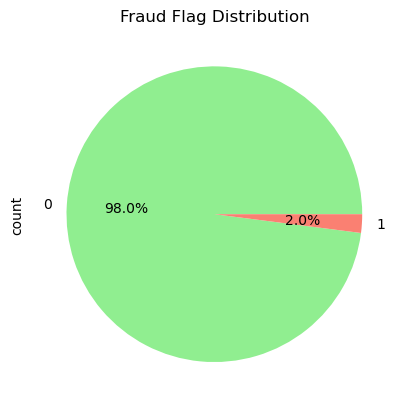

In [44]:
data['Fraud_Flag'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
plt.title('Fraud Flag Distribution')
plt.show()

In [54]:
fraud = data[data['Fraud_Flag']==1]
not_fraud = data[data['Fraud_Flag']==0]

In [56]:
X = data.drop('Fraud_Flag', axis=1)
y = data['Fraud_Flag']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [64]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [66]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.94      0.96    296856
           1       0.02      0.07      0.03      6144

    accuracy                           0.92    303000
   macro avg       0.50      0.50      0.50    303000
weighted avg       0.96      0.92      0.94    303000



In [68]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

In [72]:
conf_matrix

array([[277961,  18895],
       [  5703,    441]], dtype=int64)

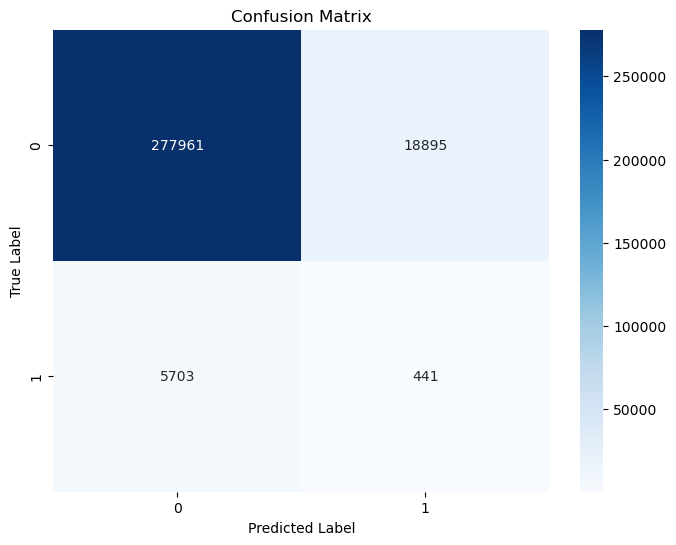

In [80]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [86]:
model_lr = LogisticRegression()
model_lr.fit(X_train_resampled, y_train_resampled)

C:\Users\Nima Dorje Lama\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [88]:
y_pred = model_lr.predict(X_test)

Accuracy: 0.65403300330033
Confusion Matrix:
 [[196135 100721]
 [  4107   2037]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.66      0.79    296856
           1       0.02      0.33      0.04      6144

    accuracy                           0.65    303000
   macro avg       0.50      0.50      0.41    303000
weighted avg       0.96      0.65      0.77    303000

ROC-AUC: 0.4961252585954975


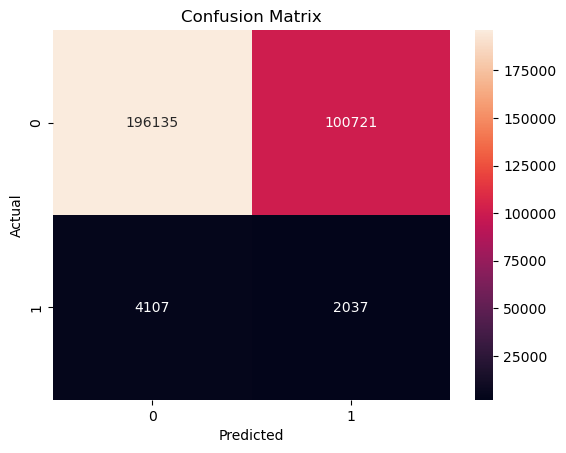

In [90]:
accuracy_lr = accuracy_score(y_test, y_pred)
conf_matrix_lr= confusion_matrix(y_test, y_pred)
class_report_lr = classification_report(y_test, y_pred)
roc_auc_lr = roc_auc_score(y_test, y_pred)

# Print Metrics
print(f'Accuracy: {accuracy_lr}')
print('Confusion Matrix:\n', conf_matrix_lr)
print('Classification Report:\n', class_report_lr)
print(f'ROC-AUC: {roc_auc_lr}')

# Plot confusion matrix
sns.heatmap(conf_matrix_lr, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [96]:
majority_downsampled = not_fraud.sample(50000)

# Combine minority class with downsampled majority class
train_data_balanced = pd.concat([majority_downsampled, fraud])

# Separate features and target variable
X_train_balanced = train_data_balanced.drop('Fraud_Flag', axis=1)
y_train_balanced = train_data_balanced['Fraud_Flag']

In [98]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_train_balanced, y_train_balanced, test_size=0.3, random_state=42, stratify=y_train_balanced)

In [100]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_d, y_train_d)

# Make predictions
y_pred_d = model.predict(X_test_d)

# Evaluate the model
print("\nClassification Report:\n", classification_report(y_test_d, y_pred_d))


Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.69      0.70     15000
           1       0.29      0.31      0.30      6144

    accuracy                           0.58     21144
   macro avg       0.50      0.50      0.50     21144
weighted avg       0.59      0.58      0.59     21144

